<a href="https://colab.research.google.com/github/marcoCodes11/Robo-Stock-Advisor/blob/main/portfolio_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  10 of 10 completed



Optimal Portfolio

AAPL: 0.00% | $0.00
MSFT: 0.00% | $0.00
JPM: 2.84% | $28,426.31
V: 15.00% | $150,000.00
JNJ: 12.19% | $121,908.69
LLY: 10.41% | $104,083.30
XOM: 15.00% | $150,000.00
CAT: 15.00% | $150,000.00
NEE: 14.56% | $145,581.70
AMZN: 15.00% | $150,000.00

Portfolio Value: $1,000,000.00
Expected Annual Return: 20.28%
Annual Volatility: 14.39%
Sharpe Ratio: 1.13

Sector Allocations

Technology: 0.00%
Financials: 17.84%
Healthcare: 22.60%
Energy: 15.00%
Industrials: 15.00%
Consumer: 29.56%

Simulations attempted: 10,000
Valid portfolios: 910


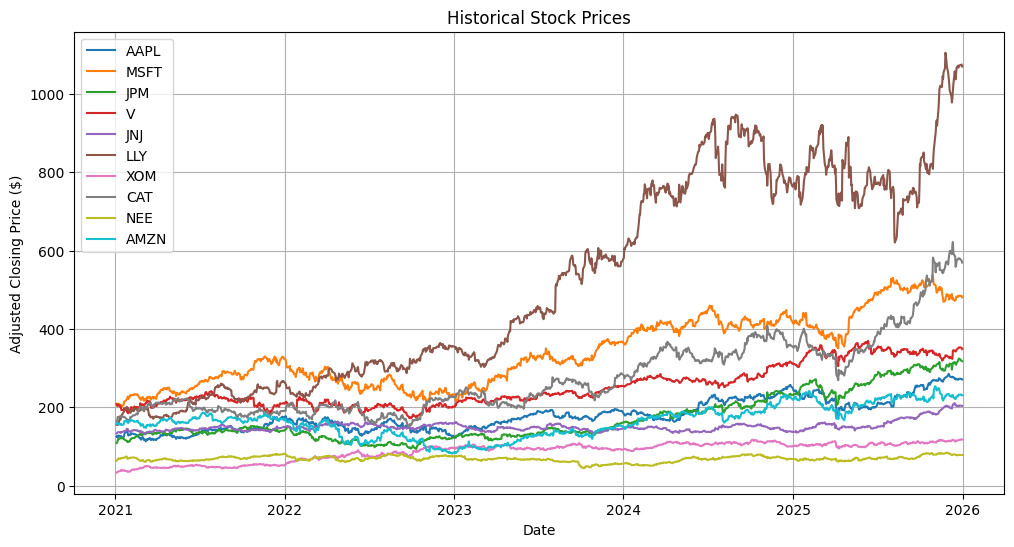

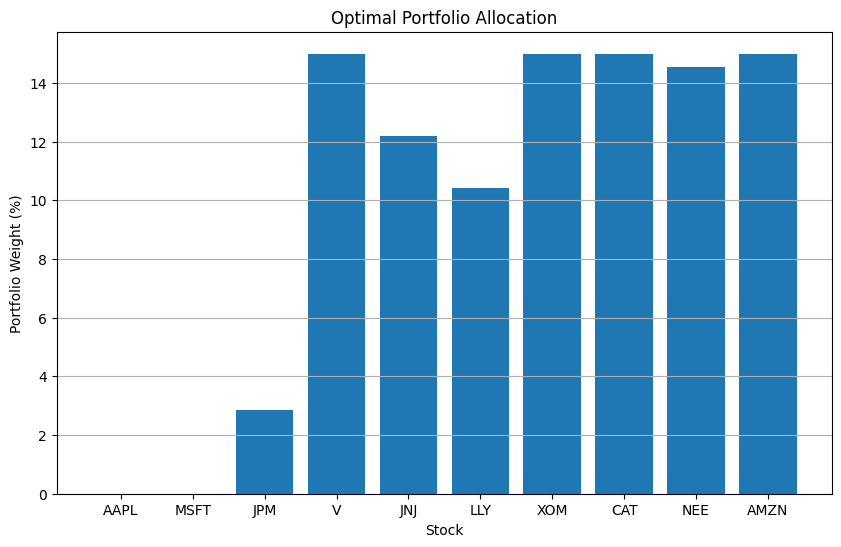

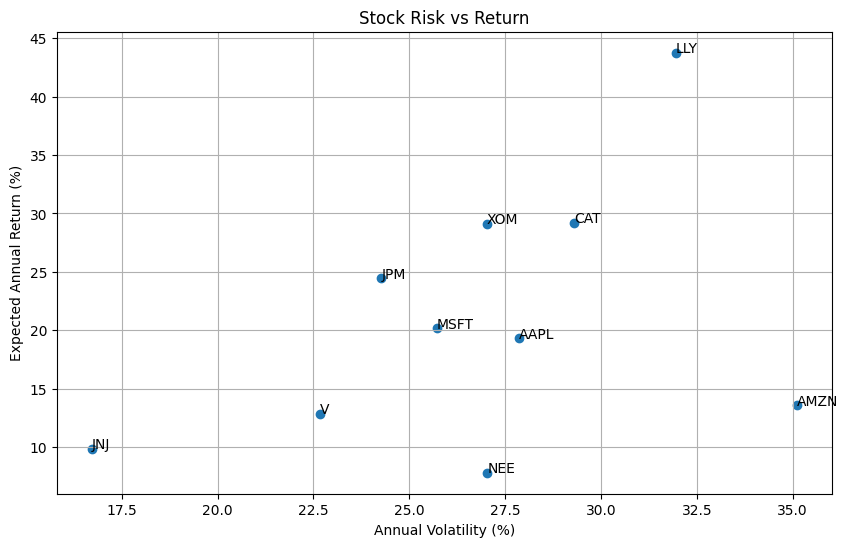

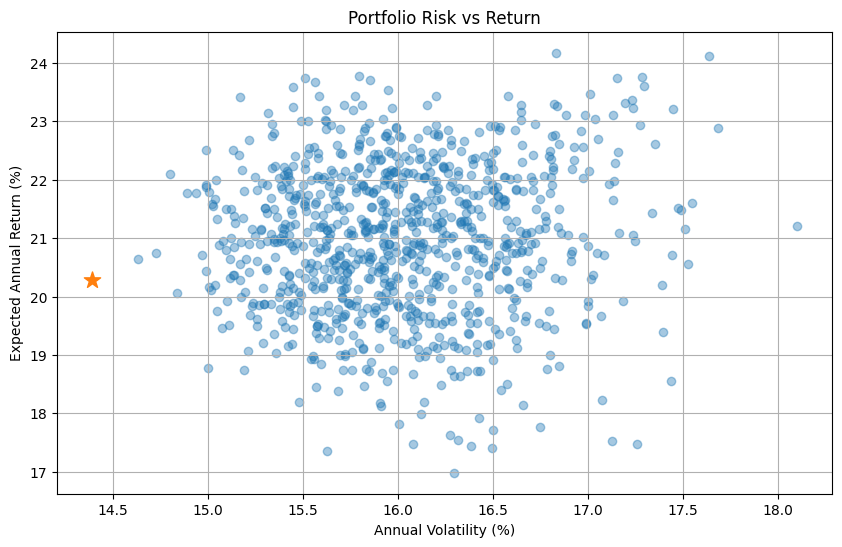

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#stocks
stocks = [
    "AAPL",
    "MSFT",
    "JPM",
    "V",
    "JNJ",
    "LLY",
    "XOM",
    "CAT",
    "NEE",
    "AMZN"
]

#historical prices (chose 5 year period, but can be adjusted)
data = yf.download(
    stocks,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]


#daily returns
returns = data.pct_change().dropna()

annual_returns = returns.mean() * 252


#annual covariance matrix
cov_matrix = returns.cov() * 252

risk_free_rate = 0.04


#calc portfolio return
def portfolio_return(weights):

    return np.dot(weights, annual_returns)


#calc portfolio volatility
def portfolio_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )


#calc sharpe ratio
def sharpe_ratio(weights):

    return (
        portfolio_return(weights)
        - risk_free_rate
    ) / portfolio_volatility(weights)


#negative because scipy minimizes
def negative_sharpe(weights):

    return -sharpe_ratio(weights)


#num of stocks
num_stocks = len(stocks)


#start with equal allocations
initial_weights = np.array(
    [1 / num_stocks] * num_stocks
)


#portfolio settings
portfolio_value = 1_000_000

stocks = [
    "AAPL", "MSFT",
    "JPM", "V",
    "JNJ", "LLY",
    "XOM", "CAT",
    "NEE", "AMZN"
]


#6 market sectors
sectors = {
    "Technology": ["AAPL", "MSFT"],
    "Financials": ["JPM", "V"],
    "Healthcare": ["JNJ", "LLY"],
    "Energy": ["XOM"],
    "Industrials": ["CAT"],
    "Consumer": ["NEE", "AMZN"]
}


num_stocks = len(stocks)


#starting portfolio weights
initial_weights = np.ones(num_stocks) / num_stocks


#portfolio must equal 100%
constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
]


#each sector can be maximum 40%
for sector, sector_stocks in sectors.items():

    indices = [
        stocks.index(stock)
        for stock in sector_stocks
    ]

    constraints.append({
        "type": "ineq",
        "fun": lambda weights, indices=indices:
            0.40 - np.sum(weights[indices])
    })


#each stock can be maximum 15%
bounds = tuple(
    (0, 0.15) for stock in stocks
)


#optimize portfolio
result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)


#check optimization worked
if not result.success:
    print("Optimization failed:", result.message)
    exit()


#optimal weights
optimal_weights = result.x


print("\nOptimal Portfolio\n")


#show each stock allocation
for stock, weight in zip(stocks, optimal_weights):

    dollar_amount = weight * portfolio_value

    print(
        f"{stock}: {weight:.2%} | "
        f"${dollar_amount:,.2f}"
    )


#portfolio statistics
optimal_return = portfolio_return(optimal_weights)

optimal_volatility = portfolio_volatility(optimal_weights)

optimal_sharpe = sharpe_ratio(optimal_weights)


print(
    f"\nPortfolio Value: "
    f"${portfolio_value:,.2f}"
)

print(
    f"Expected Annual Return: "
    f"{optimal_return:.2%}"
)

print(
    f"Annual Volatility: "
    f"{optimal_volatility:.2%}"
)

print(
    f"Sharpe Ratio: "
    f"{optimal_sharpe:.2f}"
)


#sector allocations
print("\nSector Allocations\n")

for sector, sector_stocks in sectors.items():

    sector_weight = sum(
        optimal_weights[stocks.index(stock)]
        for stock in sector_stocks
    )

    print(
        f"{sector}: "
        f"{sector_weight:.2%}"
    )


#run 10,000 portfolio simulations
num_simulations = 10_000

simulation_returns = []
simulation_volatility = []
simulation_sharpe = []


for i in range(num_simulations):

    #create random weights
    weights = np.random.random(num_stocks)

    #make weights equal 100%
    weights = weights / np.sum(weights)


    #check 15% stock limit
    if np.any(weights > 0.15):
        continue


    #check 40% sector limit
    valid_portfolio = True

    for sector, sector_stocks in sectors.items():

        sector_weight = sum(
            weights[stocks.index(stock)]
            for stock in sector_stocks
        )

        if sector_weight > 0.40:
            valid_portfolio = False
            break


    if not valid_portfolio:
        continue


    #calculate portfolio statistics
    port_return = portfolio_return(weights)

    port_volatility = portfolio_volatility(weights)

    port_sharpe = sharpe_ratio(weights)


    simulation_returns.append(port_return)

    simulation_volatility.append(port_volatility)

    simulation_sharpe.append(port_sharpe)


print(
    f"\nSimulations attempted: "
    f"{num_simulations:,}"
)

print(
    f"Valid portfolios: "
    f"{len(simulation_returns):,}"
)


#historical stock prices graph
plt.figure(figsize=(12, 6))

for stock in stocks:
    plt.plot(data.index, data[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")
plt.legend()
plt.grid(True)
plt.show()


#optimal portfolio allocation graph
plt.figure(figsize=(10, 6))

plt.bar(stocks, optimal_weights * 100)

plt.title("Optimal Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Portfolio Weight (%)")
plt.grid(axis="y")
plt.show()


#stock risk vs return graph
stock_volatility = returns.std() * np.sqrt(252)

plt.figure(figsize=(10, 6))

plt.scatter(
    stock_volatility * 100,
    annual_returns * 100
)

for stock in stocks:
    plt.annotate(
        stock,
        (
            stock_volatility[stock] * 100,
            annual_returns[stock] * 100
        )
    )

plt.title("Stock Risk vs Return")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.grid(True)
plt.show()


#portfolio simulation graph
plt.figure(figsize=(10, 6))

plt.scatter(
    np.array(simulation_volatility) * 100,
    np.array(simulation_returns) * 100,
    alpha=0.4
)


#show optimal portfolio
plt.scatter(
    optimal_volatility * 100,
    optimal_return * 100,
    s=150,
    marker="*"
)

plt.title("Portfolio Risk vs Return")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.grid(True)
plt.show()